In [ ]:
import re
import geopandas as gpd
import pandas as pd
from pathlib import Path
import numpy as np
import xarray as xr
import rioxarray  
from rasterio.features import rasterize
import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

### Get reference delineations
Download reference data for lava flows from (2023)[zenodo.org/records/10133203], (2021)[zenodo.org/records/7866738] and (2022)[zenodo.org/records/7701194]. 

Download the delineations to /labels folder, before continuing with the script.

                    min        max  count
eruption                                 
Outline      2021-03-20 2021-09-30     33
faf          2023-07-12 2023-08-20      5
lava_outline 2022-08-03 2022-09-26      7


<Axes: >

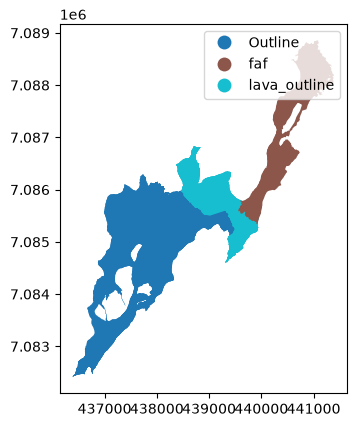

In [1]:
records = []
for f in sorted(Path("labels").glob("*.gpkg")):
    m = re.search(r"(\d{8})", f.stem)          # first 8-digit run in the name
    if m is None:
        print(f"skipping {f.name}: no date found")
        continue

    gdf = gpd.read_file(f)

    # GeoPackages usually carry their CRS; only set it if missing
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:3057")          # ISN93, the Icelandic default
    gdf = gdf.to_crs("EPSG:32627")

    gdf["date"] = pd.to_datetime(m.group(1), format="%Y%m%d")
    gdf["eruption"] = f.stem[:m.start()].strip("_")   # prefix: 'faf', 'lava_outline', 'Outline'
    records.append(gdf[["geometry", "date", "eruption"]])

outlines = pd.concat(records, ignore_index=True).sort_values("date")
print(outlines.groupby("eruption").date.agg(["min", "max", "count"]))
outlines.plot(column="eruption", legend=True)

### Rasterize labels onto the cube grid
As the outlines are time-dependent, therefore, the correct mask should be the most recent outline at or before that scene's date.

In [2]:
cube = xr.open_zarr("fagra_2021_2023.zarr")
cube = cube.rio.write_crs("EPSG:32627")
transform = cube.rio.transform()
shape = (cube.sizes["y"], cube.sizes["x"])

def mask_for(t):
    """Binary lava mask valid at time t."""
    t = pd.Timestamp(t)
    geoms = []
    for _, grp in outlines.groupby("eruption"):
        past = grp[grp.date <= t]
        if len(past):
            latest = past[past.date == past.date.max()]
            geoms += list(latest.geometry)
    if not geoms:
        return np.zeros(shape, dtype="uint8")
    return rasterize(
        [(g, 1) for g in geoms],
        out_shape=shape, transform=transform, fill=0, dtype="uint8",
    )   

labels = xr.DataArray(
    np.stack([mask_for(t) for t in cube.time.values]),
    dims=("time", "y", "x"),
    coords={"time": cube.time, "y": cube.y, "x": cube.x},
    name="lava",
)
#labels.to_dataset().to_zarr("labels.zarr", mode="w")

**Note** mask_for rasterizes once per time step, re-rasterizing from scratch each time. For now it's fine, but we could cut time here by computing one mask per unique survey date and reuse it for all scenes in between.

Check if the outlines and image overlap and match, before proceeding. Maybe good to check one of the first and last ones to see if delineations from different years and from different datasets worked.

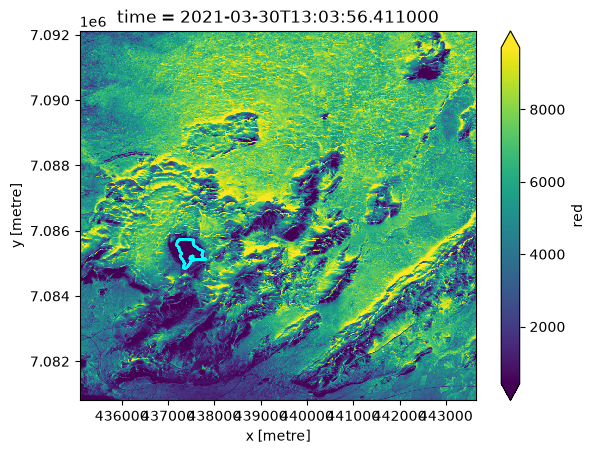

In [3]:
t = 1  # check time step
cube.red.isel(time=t).plot.imshow(robust=True)
labels.isel(time=t).plot.contour(colors="cyan")

**Note** Between surveys the outlines probably kept advancing, so a scene from between surveys gets a slightly-too-small mask. We move on for now, but later maybe dropping scenes acquired mid-eruption more than a few days from the nearest survey could help.

### Build the chip dataset

In [4]:
BANDS = ["red", "green", "blue", "nir", "swir16", "swir22"]

# (time, band, y, x) array, reflectance scaled to ~0-1
img = (cube[BANDS].to_array("band")
          .transpose("time", "band", "y", "x")
          .values.astype("float32")) / 10000.0
img = np.nan_to_num(np.clip(img, 0, 1))       # masked clouds -> 0
lab = labels.values.astype("float32")          # (time, y, x)

# also keep a validity mask so we can avoid heavily clouded chips
valid = ~np.isnan(cube.red.values)

class LavaChips(Dataset):
    def __init__(self, img, lab, valid, t_indices, chip=128, n=2000, rng_seed=0):
        self.img, self.lab, self.valid = img, lab, valid
        self.t_indices = np.asarray(t_indices)
        self.chip, self.n = chip, n
        _, _, Y, X = img.shape
        self.Y, self.X = Y - chip, X - chip
        self.rng = np.random.default_rng(rng_seed)

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        for _ in range(20):
            t = self.rng.choice(self.t_indices)
            y = self.rng.integers(self.Y)
            x = self.rng.integers(self.X)
            v = self.valid[t, y:y+self.chip, x:x+self.chip]
            if v.mean() > 0.8:
                break
        xi = self.img[t, :, y:y+self.chip, x:x+self.chip].copy()
        yi = self.lab[t, y:y+self.chip, x:x+self.chip].copy()
        if self.rng.random() < 0.5:
            xi, yi = xi[:, :, ::-1].copy(), yi[:, ::-1].copy()
        if self.rng.random() < 0.5:
            xi, yi = xi[:, ::-1, :].copy(), yi[::-1, :].copy()
        return torch.from_numpy(xi), torch.from_numpy(yi).unsqueeze(0)

Split dataset so that 2021 and 2022 are for training and 2023 for validation.

In [5]:
times = pd.to_datetime(cube.time.values)
train_t = np.where(times <  pd.Timestamp("2023-01-01"))[0]
val_t   = np.where(times >= pd.Timestamp("2023-01-01"))[0]
print(len(train_t), "training scenes,", len(val_t), "validation scenes")

36 training scenes, 20 validation scenes


Create datasets

In [6]:
train_ds = LavaChips(img, lab, valid, train_t, n=2000)
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)

### Train model

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=len(BANDS),
    classes=1,
).to(device)

dice = smp.losses.DiceLoss(mode="binary")
bce  = torch.nn.BCEWithLogitsLoss()
opt  = torch.optim.AdamW(model.parameters(), lr=1e-3)

C:\Users\b1120440\AppData\Local\miniconda3\envs\eocube\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [8]:
@torch.no_grad()
def predict_scene(t):
    x = torch.from_numpy(img[t]).unsqueeze(0)          # (1, 6, Y, X)
    _, _, Y, X = x.shape
    py, px = (32 - Y % 32) % 32, (32 - X % 32) % 32
    x = torch.nn.functional.pad(x, (0, px, 0, py))
    prob = torch.sigmoid(model(x.to(device)))[0, 0, :Y, :X]
    return prob.cpu().numpy()

In [9]:
pre2023 = labels.sel(time=slice(None, "2022-12-31")).max("time").values.astype(bool)

def iou_np(pred, target, where):
    p, t = pred & where, target & where
    union = (p | t).sum()
    return (p & t).sum() / union if union else np.nan

def evaluate():
    model.eval()
    overall, fresh = [], []
    for t in val_t:
        pred = predict_scene(t) > 0.5
        targ = lab[t].astype(bool)
        v    = valid[t]
        overall.append(iou_np(pred, targ, v))
        fresh.append(iou_np(pred, targ, v & ~pre2023))
    return np.nanmean(overall), np.nanmean(fresh)

In [20]:
for epoch in range(30):
    model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = bce(pred, yb) + dice(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()

    ov, fr = evaluate()
    print(f"epoch {epoch:02d}  overall IoU {ov:.3f}   new-lava IoU {fr:.3f}")

epoch 00  overall IoU 0.389   new-lava IoU 0.102
epoch 01  overall IoU 0.371   new-lava IoU 0.099
epoch 02  overall IoU 0.344   new-lava IoU 0.091
epoch 03  overall IoU 0.432   new-lava IoU 0.131
epoch 04  overall IoU 0.397   new-lava IoU 0.107
epoch 05  overall IoU 0.414   new-lava IoU 0.107
epoch 06  overall IoU 0.236   new-lava IoU 0.076
epoch 07  overall IoU 0.430   new-lava IoU 0.111
epoch 08  overall IoU 0.385   new-lava IoU 0.109
epoch 09  overall IoU 0.387   new-lava IoU 0.109
epoch 10  overall IoU 0.358   new-lava IoU 0.115
epoch 11  overall IoU 0.353   new-lava IoU 0.107
epoch 12  overall IoU 0.326   new-lava IoU 0.105
epoch 13  overall IoU 0.418   new-lava IoU 0.123
epoch 14  overall IoU 0.409   new-lava IoU 0.119
epoch 15  overall IoU 0.414   new-lava IoU 0.133
epoch 16  overall IoU 0.420   new-lava IoU 0.112
epoch 17  overall IoU 0.448   new-lava IoU 0.123
epoch 18  overall IoU 0.407   new-lava IoU 0.138
epoch 19  overall IoU 0.440   new-lava IoU 0.123
epoch 20  overall Io

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00029999999..1.0776].


Text(0.5, 1.0, 'prediction')

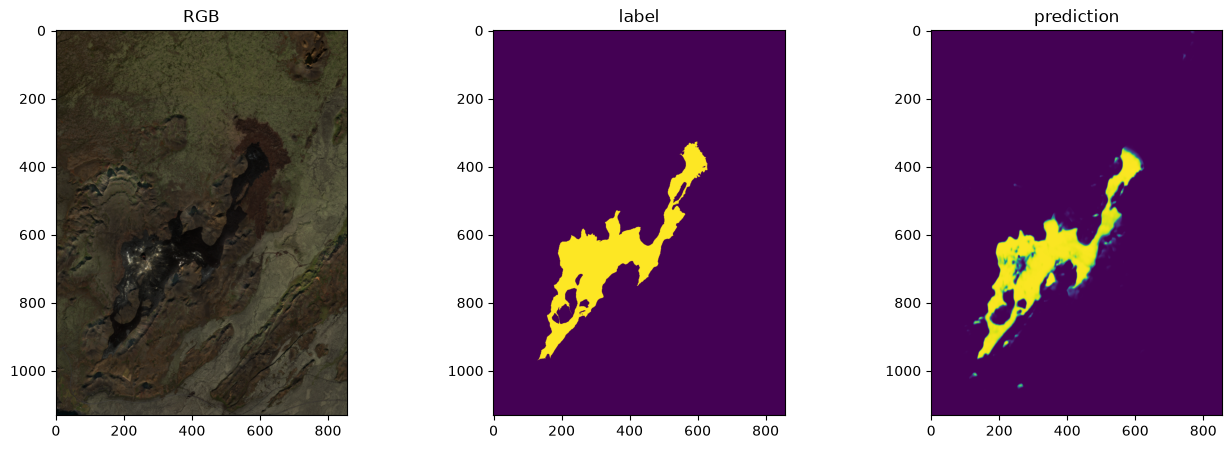

In [21]:
t = val_t[-2]   # a late-2023 scene
prob = predict_scene(t)
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(np.moveaxis(img[t, :3], 0, -1) * 3); ax[0].set_title("RGB")
ax[1].imshow(lab[t]);  ax[1].set_title("label")
ax[2].imshow(prob, vmin=0, vmax=1); ax[2].set_title("prediction")

### Save the model and predictions

Save the model weights for later.

In [ ]:
ckpt = {
    "state_dict": model.state_dict(),
    "arch": {"encoder_name": "resnet18", "in_channels": len(BANDS), "classes": 1},
    "bands": BANDS,
    "normalization": "reflectance / 10000, clipped 0-1, NaN->0",
    "epoch": epoch,
    "val_iou_overall": ov,
    "val_iou_new_lava": fr,
}
torch.save(ckpt, "unet_lava_v1.pt")

And then the predictions for the next step.

In [ ]:
probs = np.stack([predict_scene(t) for t in range(img.shape[0])])

preds = xr.Dataset(
    {
        "prob": (("time", "y", "x"), probs.astype("float32")),
        "lava": (("time", "y", "x"), (probs > 0.5).astype("uint8")),
        "valid": (("time", "y", "x"), valid),
    },
    coords={"time": cube.time, "y": cube.y, "x": cube.x},
)
preds.to_zarr("predictions.zarr", mode="w")